In [3]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dataframes
awards_players_df = pd.read_csv('../datasets/awards_players.csv')
coaches_df = pd.read_csv('../datasets/coaches.csv')
players_teams_df = pd.read_csv('../datasets/players_teams.csv')
players_df = pd.read_csv('../datasets/players.csv')
series_post_df = pd.read_csv('../datasets/series_post.csv')
teams_post_df = pd.read_csv('../datasets/teams_post.csv')
teams_df = pd.read_csv('../datasets/teams.csv')


# Exploratory Data Analysis

## General Analysis

## Coaches Performance

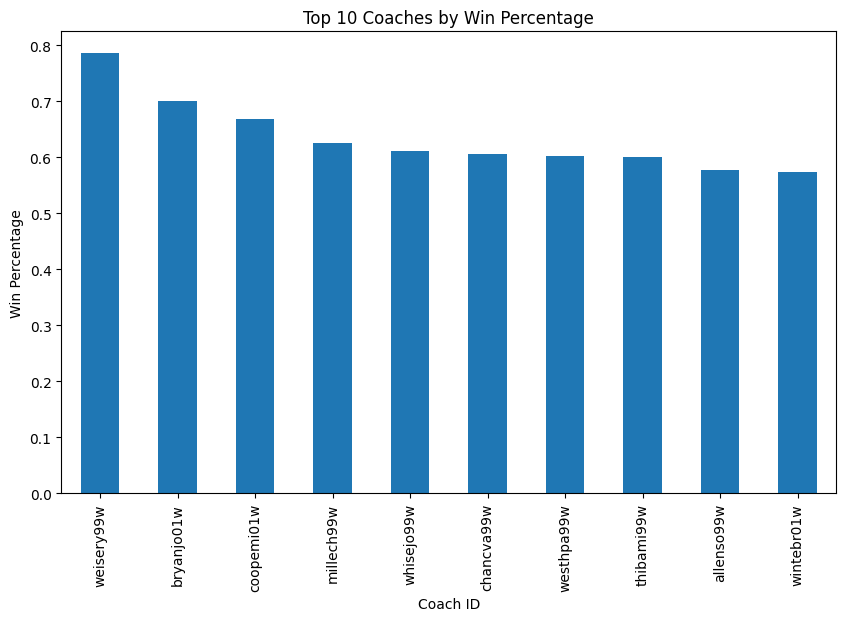

In [23]:
# Calculate win percentage for each coach
coaches_df['win_pct'] = coaches_df['won'] / (coaches_df['won'] + coaches_df['lost'])
top_coaches = coaches_df.groupby('coachID')['win_pct'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_coaches.plot(kind='bar')
plt.title('Top 10 Coaches by Win Percentage')
plt.ylabel('Win Percentage')
plt.xlabel('Coach ID')
plt.show()

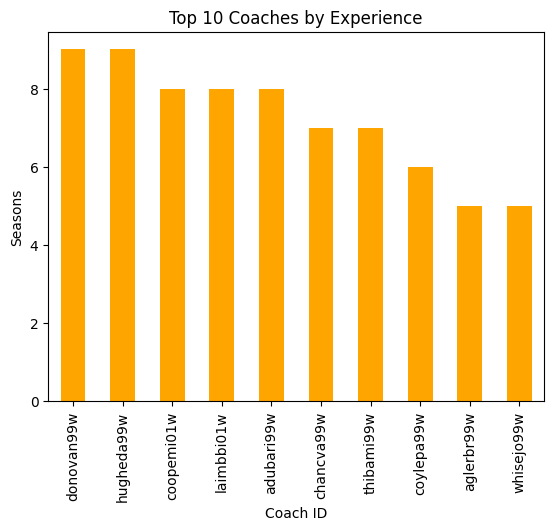

In [29]:
# Coaches with more experience (num of seasons coached)
coach_seasons = coaches_df.groupby('coachID')['year'].nunique().sort_values(ascending=False).head(10)
coach_seasons.plot(kind='bar', color='orange')
plt.title('Top 10 Coaches by Experience')
plt.xlabel('Coach ID')
plt.ylabel('Seasons')
plt.show()

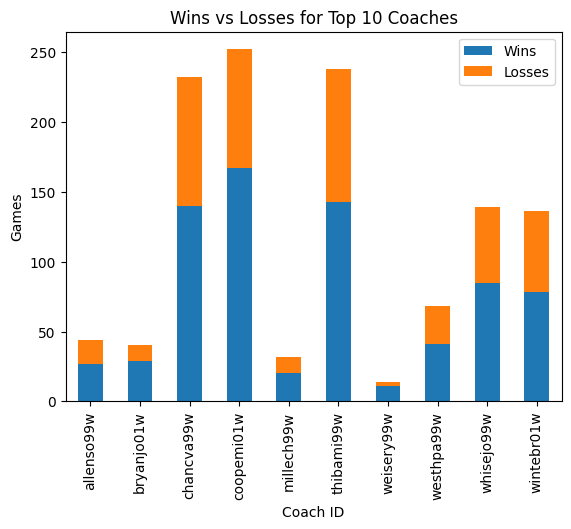

In [ ]:
# Distribution of wins and losses for top coaches
top_coach_ids = top_coaches.index.tolist()
top_coach_stats = coaches_df[coaches_df['coachID'].isin(top_coach_ids)].groupby('coachID')[['won', 'lost']].sum()

top_coach_stats.plot(kind='bar', stacked=True)

plt.title('Wins vs Losses for Top 10 Coaches')
plt.xlabel('Coach ID')
plt.ylabel('Games')
plt.legend(['Wins', 'Losses'])
plt.show()

/tmp/ipykernel_1919/1052409882.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coach_win_pct = coaches_df.groupby('coachID').apply(lambda x: x['won'].sum() / (x['won'].sum() + x['lost'].sum()))


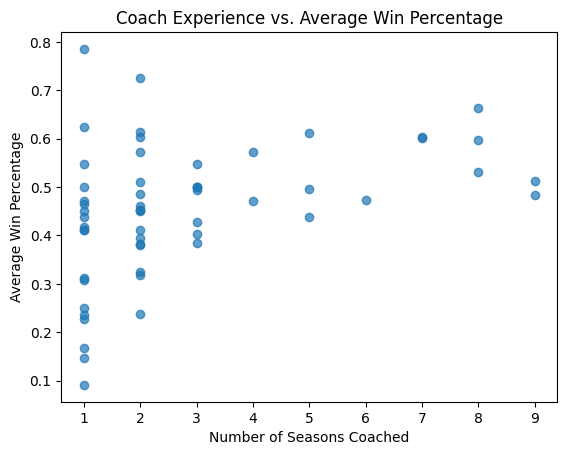

In [ ]:
# Coach experience vs. average win percentage
coach_experience = coaches_df.groupby('coachID')['year'].nunique()
coach_win_pct = coaches_df.groupby('coachID').apply(lambda x: x['won'].sum() / (x['won'].sum() + x['lost'].sum()))

plt.scatter(coach_experience, coach_win_pct, alpha=0.7)
plt.title('Coach Experience vs. Average Win Percentage')
plt.xlabel('Number of Seasons Coached')
plt.ylabel('Average Win Percentage')
plt.show()

In [35]:
# Count number of unique teams coached by each coach using the full dataset
coach_team_switches = coaches_df.groupby('coachID')['teamID'].nunique()

# Find the top 10 coaches who switched teams the most
most_switches = coach_team_switches.sort_values(ascending=False).head(10).index

# Prepare experience and win percentage for all coaches
coach_experience = coaches_df.groupby('coachID')['year'].nunique()
coach_win_pct = coaches_df.groupby('coachID').apply(lambda x: x['won'].sum() / (x['won'].sum() + x['lost'].sum()))

# Scatter plot highlighting coaches who switched teams the most
plt.figure(figsize=(10,6))
for coach in coach_experience.index:
    if coach in most_switches:
        plt.scatter(coach_experience[coach], coach_win_pct[coach], color='red', s=100, label='Switched Teams (Top 10)' if 'Switched Teams (Top 10)' not in plt.gca().get_legend_handles_labels()[1] else "")
    else:
        plt.scatter(coach_experience[coach], coach_win_pct[coach], color='blue', alpha=0.5)

plt.title('Coach Experience vs. Win Percentage (Highlighting Team Switchers)')
plt.xlabel('Number of Seasons Coached')
plt.ylabel('Average Win Percentage')
plt.legend()
plt.show()

KeyError: 'Column not found: teamID'

## Player Analysis

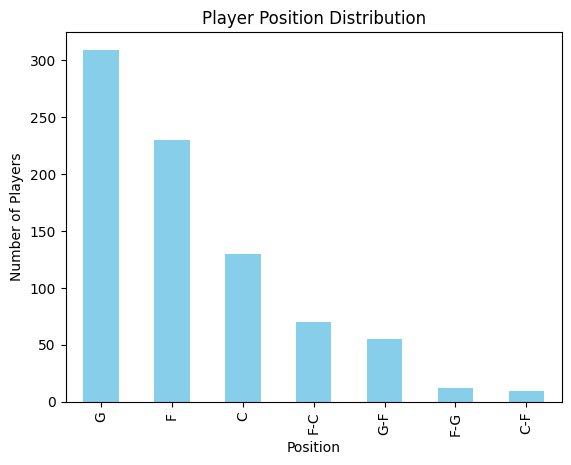

In [24]:
# Distribution of player positions
positions = players_df['pos'].value_counts()
positions.plot(kind='bar', color='skyblue')
plt.title('Player Position Distribution')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.show()

## Teams performance

year
1    256
2    256
3    256
4    238
5    221
Name: won, dtype: int64


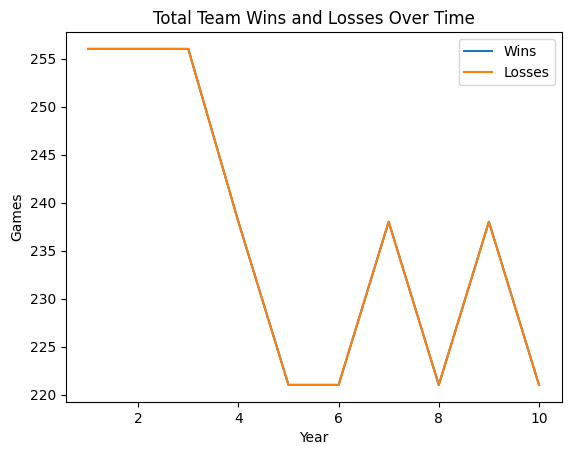

In [28]:
# Team win/loss records over time
team_wins = teams_df.groupby('year')['won'].sum()
team_losses = teams_df.groupby('year')['lost'].sum()

print(team_wins.head())

plt.plot(team_wins.index, team_wins.values, label='Wins')
plt.plot(team_losses.index, team_losses.values, label='Losses')
plt.title('Total Team Wins and Losses Over Time')
plt.xlabel('Year')
plt.ylabel('Games')
plt.legend()
plt.show()